In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw8.ipynb")

# CPSC 330 - Applied Machine Learning

## Homework 8: Introduction to Computer vision and Time Series

**Due date: See [deliverable due dates](https://ubc-cs.github.io/cpsc330-2025W2/#deliverable-due-dates-tentative)**.

## Imports

In [2]:
from hashlib import sha1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Group wotk instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   


### General submission instructions

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
  
- **Submit your files on Gradescope.**  
   - Upload only your `.ipynb` file **with outputs displayed** and any required output files.
     
   - Do **not** submit other files from your repository.  
   - If you need help, see the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- **Check that outputs render properly.**  
   - Make sure all plots and outputs appear in your submission.
     
   - If your `.ipynb` file is too large and doesn't render on Gradescope, also upload a PDF or HTML version so the TAs can view your work.  
- **Keep execution order clean.**  
   - Execution numbers must start at "1" and increase in order.
     
   - Notebooks without visible outputs may not be graded.  
   - Out-of-order or missing execution numbers may result in mark deductions.  
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 
   
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

## Exercise 1: time series prediction

In this exercise we'll be looking at a [dataset of avocado prices](https://www.kaggle.com/neuromusic/avocado-prices). You should start by downloading the dataset and storing it under the `data` folder. We will be forcasting average avocado price for the next week. 

In [3]:
df = pd.read_csv("data/avocado.csv", parse_dates=["Date"], index_col=0)
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [4]:
df.shape

(18249, 13)

In [5]:
df["Date"].min()

Timestamp('2015-01-04 00:00:00')

In [6]:
df["Date"].max()

Timestamp('2018-03-25 00:00:00')

It looks like the data ranges from the start of 2015 to March 2018 (~2 years ago), for a total of 3.25 years or so. Let's split the data so that we have a 6 months of test data.

In [7]:
split_date = '20170925'
df_train = df[df["Date"] <= split_date]
df_test  = df[df["Date"] >  split_date]

In [8]:
assert len(df_train) + len(df_test) == len(df)

<br><br>

<!-- BEGIN QUESTION -->

### 1.1 How many time series? 
rubric={points:4}

In the [Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package) dataset from lecture demo, we had different measurements for each Location. 

We want you to consider this for the avocado prices dataset. For which categorical feature(s), if any, do we have separate measurements? Justify your answer by referencing the dataset.

<div class="alert alert-warning">

Solution_1.1
    
</div>

_Points:_ 4

given the below analysis I think the categorical feautures that make sense to have seperate measurements would be the type and the region features.

In [9]:
df.sort_values(by="Date").head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
51,2015-01-04,1.75,27365.89,9307.34,3844.81,615.28,13598.46,13061.10,537.36,0.0,organic,2015,Southeast
51,2015-01-04,1.49,17723.17,1189.35,15628.27,0.00,905.55,905.55,0.00,0.0,organic,2015,Chicago
51,2015-01-04,1.68,2896.72,161.68,206.96,0.00,2528.08,2528.08,0.00,0.0,organic,2015,HarrisburgScranton
51,2015-01-04,1.52,54956.80,3013.04,35456.88,1561.70,14925.18,11264.80,3660.38,0.0,conventional,2015,Pittsburgh
51,2015-01-04,1.64,1505.12,1.27,1129.50,0.00,374.35,186.67,187.68,0.0,organic,2015,Boise


In [10]:
df.sort_values(by=["region", "Date"]).head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
51,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
51,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,2015,Albany
50,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany
50,2015-01-11,1.77,1182.56,39.00,305.12,0.00,838.44,838.44,0.00,0.0,organic,2015,Albany
49,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany


In [11]:
df.sort_values(by=["region", "type", "Date"]).head() 

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
51,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
50,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany
49,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany
48,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany
47,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.2 Equally spaced measurements? 
rubric={points:4}

In the Rain in Australia dataset, the measurements were generally equally spaced but with some exceptions. How about with this dataset? Justify your answer by referencing the dataset.

<div class="alert alert-warning">

Solution_1.2
    
</div>

_Points:_ 4

generally everything looks good only some missing measurements in the west tex new mexico but nothing crazy. there was only one case of a 2 week jump and one case of a 3 week jump but else they were all one week jumps so these cases were minor outliers and they exist at points nov 29, 2015 to dec 13, 2015 and june 11, 2017 to july 2, 2017 respectively.

In [12]:
for name, group in df.groupby(['region', 'type']):
    print("%-40s %s" % (name, group["Date"].sort_values().diff().min()))

('Albany', 'conventional')               7 days 00:00:00
('Albany', 'organic')                    7 days 00:00:00
('Atlanta', 'conventional')              7 days 00:00:00
('Atlanta', 'organic')                   7 days 00:00:00
('BaltimoreWashington', 'conventional')  7 days 00:00:00
('BaltimoreWashington', 'organic')       7 days 00:00:00
('Boise', 'conventional')                7 days 00:00:00
('Boise', 'organic')                     7 days 00:00:00
('Boston', 'conventional')               7 days 00:00:00
('Boston', 'organic')                    7 days 00:00:00
('BuffaloRochester', 'conventional')     7 days 00:00:00
('BuffaloRochester', 'organic')          7 days 00:00:00
('California', 'conventional')           7 days 00:00:00
('California', 'organic')                7 days 00:00:00
('Charlotte', 'conventional')            7 days 00:00:00
('Charlotte', 'organic')                 7 days 00:00:00
('Chicago', 'conventional')              7 days 00:00:00
('Chicago', 'organic')         

In [13]:
for name, group in df.groupby(['region', 'type']):
    print("%-40s %s" % (name, group["Date"].sort_values().diff().max()))

('Albany', 'conventional')               7 days 00:00:00
('Albany', 'organic')                    7 days 00:00:00
('Atlanta', 'conventional')              7 days 00:00:00
('Atlanta', 'organic')                   7 days 00:00:00
('BaltimoreWashington', 'conventional')  7 days 00:00:00
('BaltimoreWashington', 'organic')       7 days 00:00:00
('Boise', 'conventional')                7 days 00:00:00
('Boise', 'organic')                     7 days 00:00:00
('Boston', 'conventional')               7 days 00:00:00
('Boston', 'organic')                    7 days 00:00:00
('BuffaloRochester', 'conventional')     7 days 00:00:00
('BuffaloRochester', 'organic')          7 days 00:00:00
('California', 'conventional')           7 days 00:00:00
('California', 'organic')                7 days 00:00:00
('Charlotte', 'conventional')            7 days 00:00:00
('Charlotte', 'organic')                 7 days 00:00:00
('Chicago', 'conventional')              7 days 00:00:00
('Chicago', 'organic')         

In [14]:
name

('WestTexNewMexico', 'organic')

In [15]:
group["Date"].sort_values().diff().value_counts()

Date
7 days     163
14 days      1
21 days      1
Name: count, dtype: int64

In [16]:
group["Date"].sort_values().reset_index(drop=True).diff().sort_values()

1      7 days
106    7 days
107    7 days
108    7 days
109    7 days
        ...  
52     7 days
165    7 days
48    14 days
127   21 days
0         NaT
Name: Date, Length: 166, dtype: timedelta64[ns]

In [17]:
group["Date"].sort_values().reset_index(drop=True)[45:50]

45   2015-11-15
46   2015-11-22
47   2015-11-29
48   2015-12-13
49   2015-12-20
Name: Date, dtype: datetime64[ns]

In [18]:
group["Date"].sort_values().reset_index(drop=True)[125:130]

125   2017-06-04
126   2017-06-11
127   2017-07-02
128   2017-07-09
129   2017-07-16
Name: Date, dtype: datetime64[ns]

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.3 Interpreting regions 
rubric={points:4}

In the Rain in Australia dataset, each location was a different place in Australia. For this dataset, look at the names of the regions. Do you think the regions are also all distinct, or are there overlapping regions? Justify your answer by referencing the data.

<div class="alert alert-warning">

Solution_1.3
    
</div>

_Points:_ 4

I found some structure in that the totalUS is split into cardinal regions opposed to california is split by cities. I think that since the individual regions add up to being more than the total there must be some double counting which makes sense in the structure.

In [19]:
df["region"].unique()

array(['Albany', 'Atlanta', 'BaltimoreWashington', 'Boise', 'Boston',
       'BuffaloRochester', 'California', 'Charlotte', 'Chicago',
       'CincinnatiDayton', 'Columbus', 'DallasFtWorth', 'Denver',
       'Detroit', 'GrandRapids', 'GreatLakes', 'HarrisburgScranton',
       'HartfordSpringfield', 'Houston', 'Indianapolis', 'Jacksonville',
       'LasVegas', 'LosAngeles', 'Louisville', 'MiamiFtLauderdale',
       'Midsouth', 'Nashville', 'NewOrleansMobile', 'NewYork',
       'Northeast', 'NorthernNewEngland', 'Orlando', 'Philadelphia',
       'PhoenixTucson', 'Pittsburgh', 'Plains', 'Portland',
       'RaleighGreensboro', 'RichmondNorfolk', 'Roanoke', 'Sacramento',
       'SanDiego', 'SanFrancisco', 'Seattle', 'SouthCarolina',
       'SouthCentral', 'Southeast', 'Spokane', 'StLouis', 'Syracuse',
       'Tampa', 'TotalUS', 'West', 'WestTexNewMexico'], dtype=object)

In [20]:
df.query("region == 'TotalUS' and type == 'conventional' and Date == @pd.Timestamp('20150104')")["Total Volume"].values[0]

np.float64(31324277.73)

In [21]:
df.query("region != 'TotalUS' and type == 'conventional' and Date == @pd.Timestamp('20150104')")["Total Volume"].sum()

np.float64(51730521.73)

<!-- END QUESTION -->

<br><br>

We will use the entire dataset despite any location-based weirdness uncovered in the previous part.

We will be trying to forecast the avocado price. The function below is adapted from the lecture.

In [22]:
import pandas as pd


def create_lag_feature(
    df: pd.DataFrame,
    orig_feature: str,
    lag: int,
    groupby: list[str],
    new_feature_name: str | None = None,
    clip: bool = False,
) -> pd.DataFrame:
    """
    Create a lagged (or ahead) version of a feature, optionally per group.

    Assumes df is already sorted by time within each group and has unique indices.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset.
    orig_feature : str
        Name of the column to lag.
    lag : int
        The lag:
          - negative → values from the past (t-1, t-2, ...)
          - positive → values from the future (t+1, t+2, ...)
    groupby : list of str
        Column(s) to group by if df contains multiple time series.
    new_feature_name : str, optional
        Name of the new column. If None, a name is generated automatically.
    clip : bool, default False
        If True, drop rows where the new feature is NaN.

    Returns
    -------
    pd.DataFrame
        A new dataframe with the additional column added.
    """
    if lag == 0:
        raise ValueError("lag cannot be 0 (no shift). Use the original feature instead.")

    # Default name if not provided
    if new_feature_name is None:
        if lag < 0:
            new_feature_name = f"{orig_feature}_lag{abs(lag)}"
        else:
            new_feature_name = f"{orig_feature}_ahead{lag}"

    df = df.copy()

    # Map your convention (negative=past, positive=future) to pandas shift
    # pandas: shift(+k) → past, shift(-k) → future
    periods = abs(lag) if lag < 0 else -lag

    df[new_feature_name] = (
        df.groupby(groupby, sort=False)[orig_feature]
          .shift(periods)
    )

    if clip:
        df = df.dropna(subset=[new_feature_name])

    return df


We first sort our dataframe properly:

In [23]:
df_sort = df.sort_values(by=["region", "type", "Date"]).reset_index(drop=True)
df_sort

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-25,1.57,18421.24,1974.26,2482.65,0.00,13964.33,13698.27,266.06,0.0,organic,2018,WestTexNewMexico
18245,2018-03-04,1.54,17393.30,1832.24,1905.57,0.00,13655.49,13401.93,253.56,0.0,organic,2018,WestTexNewMexico
18246,2018-03-11,1.56,22128.42,2162.67,3194.25,8.93,16762.57,16510.32,252.25,0.0,organic,2018,WestTexNewMexico
18247,2018-03-18,1.56,15896.38,2055.35,1499.55,0.00,12341.48,12114.81,226.67,0.0,organic,2018,WestTexNewMexico


We then call `create_lag_feature`. This creates a new column in the dataset `AveragePriceNextWeek`, which is the following week's `AveragePrice`. We have set `clip=True` which means it will remove rows where the target would be missing.

In [24]:
df_hastarget = create_lag_feature(df_sort, "AveragePrice", +1, ["region", "type"], "AveragePriceNextWeek", clip=True)
df_hastarget

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,1.24
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,1.17
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,1.06
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,0.99
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18243,2018-02-18,1.56,17597.12,1892.05,1928.36,0.00,13776.71,13553.53,223.18,0.0,organic,2018,WestTexNewMexico,1.57
18244,2018-02-25,1.57,18421.24,1974.26,2482.65,0.00,13964.33,13698.27,266.06,0.0,organic,2018,WestTexNewMexico,1.54
18245,2018-03-04,1.54,17393.30,1832.24,1905.57,0.00,13655.49,13401.93,253.56,0.0,organic,2018,WestTexNewMexico,1.56
18246,2018-03-11,1.56,22128.42,2162.67,3194.25,8.93,16762.57,16510.32,252.25,0.0,organic,2018,WestTexNewMexico,1.56


Our goal is to predict `AveragePriceNextWeek`. 

Let's split the data:

In [25]:
df_train = df_hastarget[df_hastarget["Date"] <= split_date]
df_test  = df_hastarget[df_hastarget["Date"] >  split_date]

<br><br>

<!-- BEGIN QUESTION -->

### 1.4 `AveragePrice` baseline 
rubric={points}

Soon we will want to build some models to forecast the average avocado price a week in advance. Before we start with any ML though, let's try a baseline. Previously we used `DummyClassifier` or `DummyRegressor` as a baseline. This time, we'll do something else as a baseline: we'll assume the price stays the same from this week to next week. So, we'll set our prediction of "AveragePriceNextWeek" exactly equal to "AveragePrice", assuming no change. That is kind of like saying, "If it's raining today then I'm guessing it will be raining tomorrow". This simplistic approach will not get a great score but it's a good starting point for reference. If our model does worse that this, it must not be very good. 

Using this baseline approach, what $R^2$ do you get on the train and test data?

<div class="alert alert-warning">

Solution_1.4
    
</div>

_Points:_ 4

_Type your answer here, replacing this text._

In [26]:
train_r2 = None

train_r2 = r2_score(df_train["AveragePriceNextWeek"], df_train["AveragePrice"])
train_r2

0.8285800937261841

In [27]:
test_r2 = None

test_r2 = r2_score(df_test["AveragePriceNextWeek"], df_test["AveragePrice"])
test_r2

0.7631780188583048

In [28]:
df_test["AveragePrice"]

143      1.69
144      1.78
145      1.65
146      1.56
147      1.67
         ... 
18243    1.56
18244    1.57
18245    1.54
18246    1.56
18247    1.56
Name: AveragePrice, Length: 2700, dtype: float64

In [29]:
df_test["AveragePriceNextWeek"]

143      1.78
144      1.65
145      1.56
146      1.67
147      1.62
         ... 
18243    1.57
18244    1.54
18245    1.56
18246    1.56
18247    1.62
Name: AveragePriceNextWeek, Length: 2700, dtype: float64

In [30]:
assert not train_r2 is None, "Are you using the correct variable name?"
assert not test_r2 is None, "Are you using the correct variable name?"
assert sha1(str(round(train_r2, 3)).encode('utf8')).hexdigest() == 'b1136fe2a8918904393ab6f40bfb3f38eac5fc39', "Your training score is not correct. Are you using the right features?"
assert sha1(str(round(test_r2, 3)).encode('utf8')).hexdigest() == 'cc24d9a9b567b491a56b42f7adc582f2eefa5907', "Your test score is not correct. Are you using the right features?"

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.5 Forecasting average avocado price
rubric={points:10}

Now that the baseline is done, let's build some models to forecast the average avocado price a week later. Experiment with a few approachs for encoding the date. Justify the decisions you make. Which approach worked best? Report your test score and briefly discuss your results.

Benchmark: you should be able to achieve $R^2$ of at least 0.79 on the test set. I got to 0.80, but not beyond that. Let me know if you do better!

Note: because we only have 2 splits here, we need to be a bit wary of overfitting on the test set. Try not to test on it a ridiculous number of times. If you are interested in some proper ways of dealing with this, see for example sklearn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html), which is like cross-validation for time series data.

<div class="alert alert-warning">

Solution_1.5
    
</div>

_Points:_ 10

To forecast the average avocado price one week ahead, I experimented with several approaches for encoding the date feature. First, I used the raw year feature along with other predictors, which allowed the model to capture a general time trend but did not explicitly model seasonality. This approach achieved a test R2 of **0.788**, slightly below the benchmark given above 

Overall, the best-performing approach I found was the model that combined month encoding (seasonality) with other features, achieving a test R2 of approximately 0.8. While lag features slightly improved training performance, they did not meaningfully increase test performance, showing signs of possible mild overfitting.

In [31]:
df_train.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,1.24
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,1.17
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,1.06
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,0.99
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,0.99


In [32]:
(df_train.loc[:, "Small Bags": "XLarge Bags"].sum(axis=1) - df_train["Total Bags"]).abs().max()

np.float64(1.0)

In [33]:
(df_train.loc[:, "4046": "4770"].sum(axis=1) - df_train["Total Volume"]).abs().max()

np.float64(16298296.29)

In [34]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15441 entries, 0 to 18222
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  15441 non-null  datetime64[ns]
 1   AveragePrice          15441 non-null  float64       
 2   Total Volume          15441 non-null  float64       
 3   4046                  15441 non-null  float64       
 4   4225                  15441 non-null  float64       
 5   4770                  15441 non-null  float64       
 6   Total Bags            15441 non-null  float64       
 7   Small Bags            15441 non-null  float64       
 8   Large Bags            15441 non-null  float64       
 9   XLarge Bags           15441 non-null  float64       
 10  type                  15441 non-null  object        
 11  year                  15441 non-null  int64         
 12  region                15441 non-null  object        
 13  AveragePriceNextWeek 

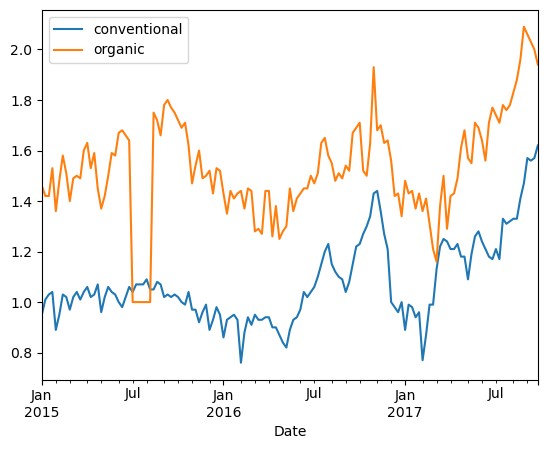

In [35]:
df_train.query("region == 'TotalUS'").set_index("Date").groupby("type")["AveragePrice"].plot(legend=True);

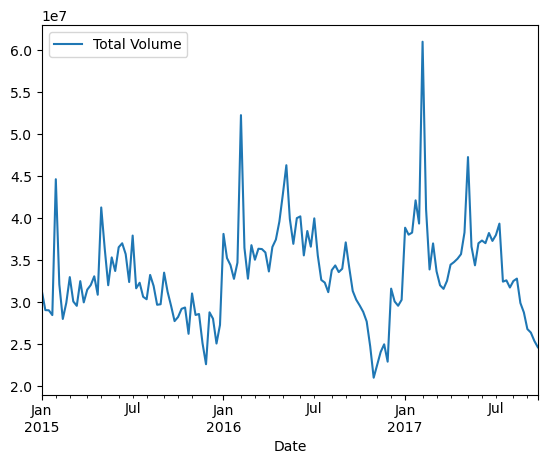

In [36]:
df_train.query("region == 'TotalUS' and type == 'conventional'").plot(x="Date", y="Total Volume");

In [37]:
numeric_features     = ["Total Volume", "4046", "4225", "4770", "Small Bags", "Large Bags", "XLarge Bags", "year"]
categorical_features = ["type", "region"]
keep_features        = ["AveragePrice"]
drop_features        = ["Date", "Total Bags"] 
target_feature       = "AveragePriceNextWeek"

In [38]:
def preprocess_features(df_train, df_test, numeric_features, categorical_features, keep_features, drop_features, target_feature):
    
    all_features = numeric_features + categorical_features + keep_features + drop_features + [target_feature]
    if set(df_train.columns) != set(all_features):
        print("Missing columns", set(df_train.columns) - set(all_features))
        print("Extra columns", set(all_features) - set(df_train.columns))
        raise Exception("Columns do not match")
        

    df_train = df_train[all_features]
    df_test = df_test[all_features]
    
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first'))
    ])
    preprocessor = ColumnTransformer([
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features),
        ('passthrough', 'passthrough', keep_features),
        ('drop', 'drop', drop_features + [target_feature])
    ])
    preprocessor.fit(df_train);

    if len(categorical_features) > 0:
        ohe = preprocessor.named_transformers_['categorical'].named_steps['onehot']
        ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))
        new_columns = numeric_features + ohe_feature_names + keep_features
    else:
        new_columns = numeric_features + keep_features

    X_train_enc = pd.DataFrame(data=preprocessor.transform(df_train).toarray(), index=df_train.index, columns=new_columns)
    X_test_enc  = pd.DataFrame(data=preprocessor.transform(df_test).toarray(),  index=df_test.index,  columns=new_columns)
    
    y_train = df_train[target_feature]
    y_test  = df_test[ target_feature]
    
    return X_train_enc, y_train, X_test_enc, y_test

In [39]:
df_train_enc, y_train, df_test_enc, y_test = preprocess_features(df_train, df_test, numeric_features, categorical_features, keep_features, drop_features, target_feature)

In [40]:
df_train_enc

,Total Volume,4046,4225,4770,Small Bags,Large Bags,XLarge Bags,year,type_organic,region_Atlanta,...,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico,AveragePrice
0,-0.234535,-0.229503,-0.222203,-0.214954,-0.229907,-0.223154,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.22
1,-0.234440,-0.230948,-0.219448,-0.214272,-0.231513,-0.223789,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.24
2,-0.233469,-0.231018,-0.219530,-0.214196,-0.226469,-0.224325,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.17
3,-0.233283,-0.230996,-0.218170,-0.213945,-0.228629,-0.222193,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.06
4,-0.225747,-0.230668,-0.196131,-0.213811,-0.229930,-0.224856,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18218,-0.241780,-0.229664,-0.242429,-0.215395,-0.229029,-0.225402,-0.172063,1.376692,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.50
18219,-0.244264,-0.231008,-0.242114,-0.215395,-0.239057,-0.225344,-0.172063,1.376692,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.39
18220,-0.243034,-0.230503,-0.241696,-0.215395,-0.234745,-0.225499,-0.172063,1.376692,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.38
18221,-0.243442,-0.230278,-0.243130,-0.215395,-0.234638,-0.225529,-0.172063,1.376692,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.36


In [41]:
lr = Ridge()
lr.fit(df_train_enc, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [42]:
lr.score(df_train_enc, y_train)

0.8451121096743694

In [43]:
lr.score(df_test_enc, y_test)

0.7879252704467027

In [44]:
lr_coef = pd.DataFrame(data=np.squeeze(lr.coef_), index=df_train_enc.columns, columns=["Coef"])
lr_coef.sort_values(by="Coef", ascending=False)

,Coef
AveragePrice,0.802224
type_organic,0.099166
region_SanFrancisco,0.060399
region_HartfordSpringfield,0.057964
region_NewYork,0.040027
...,...
region_CincinnatiDayton,-0.071877
region_Denver,-0.073122
region_SouthCentral,-0.093012
region_DallasFtWorth,-0.093052


In [45]:
lr_coef.loc["year"]

Coef    0.015609
Name: year, dtype: float64

In [46]:
df_train_month = df_train.assign(Month=df_train["Date"].apply(lambda x: x.month))
df_test_month  = df_test.assign( Month=df_test[ "Date"].apply(lambda x: x.month))

In [47]:
df_train_month_enc, y_train, df_test_month_enc, y_test = preprocess_features(df_train_month, df_test_month, 
                        numeric_features, 
                        categorical_features + ["Month"], 
                        keep_features, 
                        drop_features, 
                        target_feature)

In [48]:
df_train_month_enc.head()

,Total Volume,4046,4225,4770,Small Bags,Large Bags,XLarge Bags,year,type_organic,region_Atlanta,...,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,AveragePrice
0,-0.234535,-0.229503,-0.222203,-0.214954,-0.229907,-0.223154,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.22
1,-0.234440,-0.230948,-0.219448,-0.214272,-0.231513,-0.223789,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.24
2,-0.233469,-0.231018,-0.219530,-0.214196,-0.226469,-0.224325,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.17
3,-0.233283,-0.230996,-0.218170,-0.213945,-0.228629,-0.222193,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.06
4,-0.225747,-0.230668,-0.196131,-0.213811,-0.229930,-0.224856,-0.172063,-1.147053,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.99


In [49]:
lr = Ridge()
lr.fit(df_train_month_enc, y_train);
print(lr.score(df_train_month_enc, y_train))
print(lr.score(df_test_month_enc, y_test))

0.849364682554632
0.800129326897269


In [50]:
pd.DataFrame(data=np.squeeze(lr.coef_), index=df_train_month_enc.columns, columns=["Coef"]).sort_values(by="Coef", ascending=False)

,Coef
AveragePrice,0.771853
type_organic,0.114584
Month_9,0.098114
Month_8,0.081332
Month_7,0.069596
...,...
region_CincinnatiDayton,-0.083448
region_Denver,-0.084731
region_SouthCentral,-0.106716
region_DallasFtWorth,-0.107661


In [51]:
def add_lags(df):
    df = create_lag_feature(df, "AveragePrice", -1, ["region", "type"])
    df = create_lag_feature(df, "AveragePrice", -2, ["region", "type"])
    df = create_lag_feature(df, "AveragePrice", -3, ["region", "type"])
    df = create_lag_feature(df, "AveragePrice", -4, ["region", "type"])
    return df

df_train_month_lag = add_lags(df_train_month)
df_test_month_lag  = add_lags(df_test_month)
df_train_month_lag

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek,Month,AveragePrice_lag1,AveragePrice_lag2,AveragePrice_lag3,AveragePrice_lag4
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,1.24,1,NaN,NaN,NaN,NaN
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,1.17,1,1.22,NaN,NaN,NaN
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,1.06,1,1.24,1.22,NaN,NaN
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,0.99,1,1.17,1.24,1.22,NaN
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,0.99,2,1.06,1.17,1.24,1.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18218,2017-08-27,2.50,16137.93,2616.96,3672.96,0.00,9848.01,9816.58,31.43,0.0,organic,2017,WestTexNewMexico,2.39,8,2.43,2.01,1.78,1.67
18219,2017-09-03,2.39,7657.47,927.27,4056.73,0.00,2673.47,2629.18,44.29,0.0,organic,2017,WestTexNewMexico,2.38,9,2.50,2.43,2.01,1.78
18220,2017-09-10,2.38,11857.31,1562.10,4565.41,0.00,5729.80,5719.96,9.84,0.0,organic,2017,WestTexNewMexico,2.36,9,2.39,2.50,2.43,2.01
18221,2017-09-17,2.36,10464.29,1845.14,2819.17,0.00,5799.98,5796.65,3.33,0.0,organic,2017,WestTexNewMexico,2.26,9,2.38,2.39,2.50,2.43


In [52]:
df_train_month_lag_enc, y_train, df_test_month_lag_enc, y_test = preprocess_features(df_train_month_lag, df_test_month_lag, 
                        numeric_features + ["AveragePrice_lag1", "AveragePrice_lag2", "AveragePrice_lag3", "AveragePrice_lag4"], 
                        categorical_features + ["Month"], 
                        keep_features, 
                        drop_features, 
                        target_feature)

In [53]:
lr = Ridge()
lr.fit(df_train_month_lag_enc, y_train);
print(lr.score(df_train_month_lag_enc, y_train))
print(lr.score(df_test_month_lag_enc, y_test))

0.8595737220705675
0.7999284008145044


In [54]:
pd.DataFrame(data=np.squeeze(lr.coef_), index=df_train_month_lag_enc.columns, columns=["Coef"]).sort_values(by="Coef", ascending=False)

,Coef
AveragePrice,0.578971
Month_9,0.080655
type_organic,0.068920
Month_8,0.068412
Month_7,0.062242
...,...
region_CincinnatiDayton,-0.046909
region_Denver,-0.049935
region_SouthCentral,-0.061838
region_DallasFtWorth,-0.063216


<!-- END QUESTION -->

<br><br><br><br>

## Exercise 2: Short answer questions

<!-- BEGIN QUESTION -->

### 2.1 Time series

rubric={points:6}

The following questions pertain to Lecture 20 on time series data:

1. Sometimes a time series has missing time points or, worse, time points that are unequally spaced in general. Give an example of a real world situation where the time series data would have unequally spaced time points.
2. In class we discussed two approaches to using temporal information: encoding the date as one or more features, and creating lagged versions of features. Which of these (one/other/both/neither) two approaches would struggle with unequally spaced time points? Briefly justify your answer.
3. When studying time series modeling, we explored several ways to encode date information as a feature for the citibike dataset. When we used time of day as a numeric feature, the Ridge model was not able to capture the periodic pattern. Why? How did we tackle this problem? Briefly explain.

<div class="alert alert-warning">

Solution_2.1
    
</div>

_Points:_ 6

1. anytime when the frequency of the measurement cannot be made simply by a human taking them ie; credit card transactions
2. encoding the date as one hot encoding can work on unequally spaced points but the lag feature has issue in that since the old measurement will be at some different length of time away for each case.
3. when encoding the time of day as an integer and giving it to a linear model there is no periodic pattern seen as the linar model, as the naem suggests only can learn the linear function of some numeric. Can be fixed with the one hot encoding aformentioned 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 2.2 Computer vision 
rubric={points:6}

The following questions pertain to the lecture on multiclass classification and introduction to computer vision. 

1. How many parameters (coefficients and intercepts) will `sklearn`’s `LogisticRegression()` model learn for a four-class classification problem, assuming that you have 10 features? Briefly explain your answer.
2. In Lecture 19, we briefly discussed how neural networks are sort of like `sklearn`'s pipelines, in the sense that they involve multiple sequential transformations of the data, finally resulting in the prediction. Why was this property useful when it came to transfer learning?
3. Imagine that you have a small dataset with ~1000 images containing pictures and names of 50 different Computer Science faculty members from UBC. Your goal is to develop a reasonably accurate multi-class classification model for this task. Describe which model/technique you would use and briefly justify your choice in one to three sentences.

<div class="alert alert-warning">

Solution_2.2
    
</div>

_Points:_ 6

1. 10 coefficents for 10 features and either an intercept or bias term for each of the class.
2. its useful because we can then keep a majority of the transformations and only replace the last with a more task specific one.
3. By using a pretrained model one thats preferable availble open sourced and trained on a larger dataset. Using that model as a feature extractor and train a RF model on the said extracted features it gathers to classify the faculty members. 

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Submission Instructions section at the top. 

Here is a quick checklist before submitting: 

- [ ] Restart kernel, clear outputs, and run all cells from top to bottom.  
- [ ] `.ipynb` file runs without errors and contains all outputs.  
- [ ] Only `.ipynb` and required output files are uploaded (no extra files).  
- [ ] Execution numbers start at **1** and are in order.  
- [ ] If `.ipynb` is too large and doesn't render on Gradescope, also upload a PDF/HTML version.  
- [ ] Reviewed the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions).  

![](img/eva-well-done.png)